In [1]:
from ema_workbench import (
    Model,
    MultiprocessingEvaluator,
    ScalarOutcome,
    IntegerParameter,
    optimize,
    Scenario,
)
from ema_workbench.em_framework.optimization import EpsilonProgress
from ema_workbench.util import ema_logging
from problem_formulation import get_model_for_problem_formulation
import matplotlib.pyplot as plt
import seaborn as sns

<class 'ema_workbench.em_framework.model.Model'>


[MainProcess/INFO] pool started with 12 workers
100%|████████████████████████████████████████| 200/200 [00:18<00:00, 11.01it/s]
[MainProcess/INFO] optimization completed, found 95 solutions
[MainProcess/INFO] terminating pool


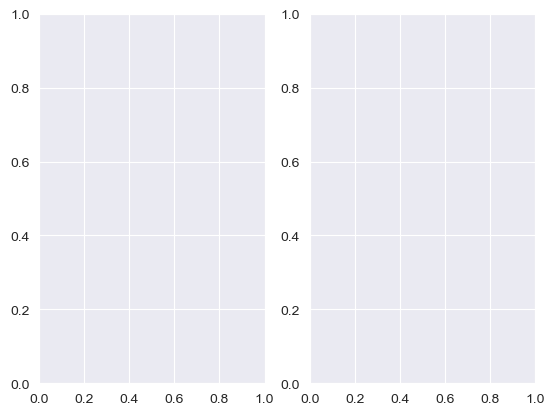

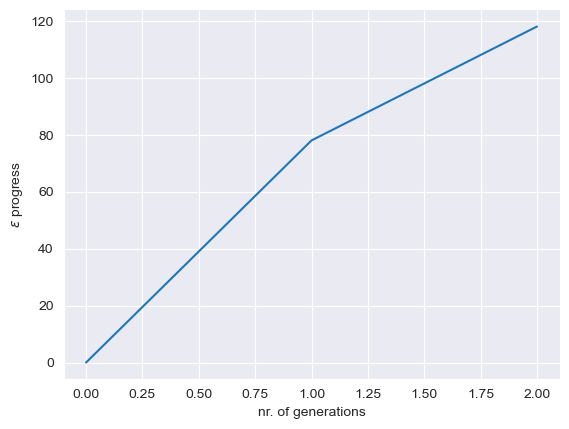

In [2]:
if __name__ == "__main__":
    ema_logging.log_to_stderr(ema_logging.INFO)

    model, steps = get_model_for_problem_formulation(3)
    print(type(model))

    reference_values = {
        "Bmax": 175,
        "Brate": 1.5,
        "pfail": 0.5,
        "discount rate 0": 3.5,
        "discount rate 1": 3.5,
        "discount rate 2": 3.5,
        "ID flood wave shape": 4,
    }
    scen1 = {}

    for key in model.uncertainties:
        name_split = key.name.split("_")

        if len(name_split) == 1:
            scen1.update({key.name: reference_values[key.name]})

        else:
            scen1.update({key.name: reference_values[name_split[1]]})

    ref_scenario = Scenario("reference", **scen1)

    convergence_metrics = [EpsilonProgress()]

    espilon = [1e3] * len(model.outcomes)

    nfe = 200  # proof of principle only, way to low for actual use

    with MultiprocessingEvaluator(model) as evaluator:
        results, convergence = evaluator.optimize(
            nfe=nfe,
            searchover="levers",
            epsilons=espilon,
            convergence=convergence_metrics,
            reference=ref_scenario,
        )

    fig, (ax1, ax2) = plt.subplots(ncols=2, sharex=True)
    fig, ax1 = plt.subplots(ncols=1)
    ax1.plot(convergence.epsilon_progress)
    ax1.set_xlabel("nr. of generations")
    ax1.set_ylabel(r"$\epsilon$ progress")
    sns.despine()


In [3]:
for i in model.outcomes:
    print(i)

ScalarOutcome('A.1 Total Costs', variable_name=('A.1_Expected Annual Damage', 'A.1_Dike Investment Costs'), function=<function sum_over at 0x00000239F58313A0>)
ScalarOutcome('A.1_Expected Number of Deaths', variable_name=('A.1_Expected Number of Deaths',), function=<function sum_over at 0x00000239F58313A0>)
ScalarOutcome('A.2 Total Costs', variable_name=('A.2_Expected Annual Damage', 'A.2_Dike Investment Costs'), function=<function sum_over at 0x00000239F58313A0>)
ScalarOutcome('A.2_Expected Number of Deaths', variable_name=('A.2_Expected Number of Deaths',), function=<function sum_over at 0x00000239F58313A0>)
ScalarOutcome('A.3 Total Costs', variable_name=('A.3_Expected Annual Damage', 'A.3_Dike Investment Costs'), function=<function sum_over at 0x00000239F58313A0>)
ScalarOutcome('A.3_Expected Number of Deaths', variable_name=('A.3_Expected Number of Deaths',), function=<function sum_over at 0x00000239F58313A0>)
ScalarOutcome('A.4 Total Costs', variable_name=('A.4_Expected Annual Dama

C:\Users\milan\PycharmProjects\EMAworkbench\ema_workbench\analysis\parcoords.py:220: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(h_pad=0, w_pad=0)


<Figure size 6000x1200 with 0 Axes>

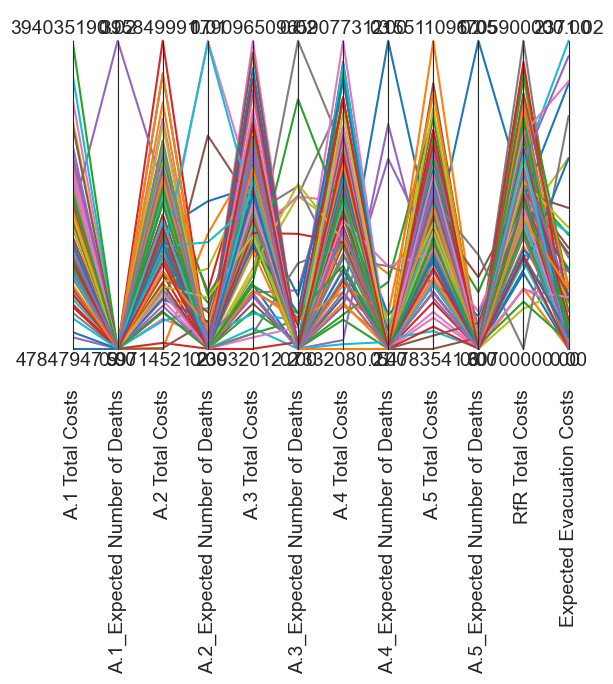

In [3]:
import matplotlib.pyplot as plt
from ema_workbench.analysis import parcoords

data = results.loc[:, [o.name for o in model.outcomes]]
limits = parcoords.get_limits(data)

plt.figure(figsize=(60, 12))  # make the figure wider; adjust numbers as you want

paraxes = parcoords.ParallelAxes(limits)
paraxes.plot(data)

plt.show()

In [4]:
import random

random.seed(20)

In [8]:
import os
from ema_workbench.em_framework.optimization import ArchiveLogger, EpsilonProgress
from ema_workbench import MultiprocessingEvaluator

# Zorg dat de map bestaat
os.makedirs("./archives", exist_ok=True)

# Verwijder bestaand bestand indien nodig
archive_path = "./archives/assignment_9_1.tar.gz"
if os.path.exists(archive_path):
    os.remove(archive_path)

# Convergence metrics
convergence_metrics = [
    ArchiveLogger(
        "./archives",
        [l.name for l in model.levers],
        [o.name for o in model.outcomes],
        base_filename="assignment_9_1.tar.gz",
    ),
    EpsilonProgress(),
]

# Run de optimalisatie
with MultiprocessingEvaluator(model) as evaluator:
    results, convergence = evaluator.optimize(
        nfe=1000,
        searchover='levers',
        convergence=convergence_metrics,
        epsilons=[0.01] * len(model.outcomes),
        reference=ref_scenario
    )

[MainProcess/INFO] pool started with 12 workers
100%|██████████████████████████████████████| 1000/1000 [01:28<00:00, 11.33it/s]
[MainProcess/INFO] optimization completed, found 207 solutions
[MainProcess/INFO] terminating pool


In [9]:
archives = ArchiveLogger.load_archives("./archives/assignment_9_1.tar.gz")

In [11]:
archives

{0: Empty DataFrame
 Columns: [0_RfR 0, 0_RfR 1, 0_RfR 2, 1_RfR 0, 1_RfR 1, 1_RfR 2, 2_RfR 0, 2_RfR 1, 2_RfR 2, 3_RfR 0, 3_RfR 1, 3_RfR 2, 4_RfR 0, 4_RfR 1, 4_RfR 2, EWS_DaysToThreat, A.1_DikeIncrease 0, A.1_DikeIncrease 1, A.1_DikeIncrease 2, A.2_DikeIncrease 0, A.2_DikeIncrease 1, A.2_DikeIncrease 2, A.3_DikeIncrease 0, A.3_DikeIncrease 1, A.3_DikeIncrease 2, A.4_DikeIncrease 0, A.4_DikeIncrease 1, A.4_DikeIncrease 2, A.5_DikeIncrease 0, A.5_DikeIncrease 1, A.5_DikeIncrease 2, A.1 Total Costs, A.1_Expected Number of Deaths, A.2 Total Costs, A.2_Expected Number of Deaths, A.3 Total Costs, A.3_Expected Number of Deaths, A.4 Total Costs, A.4_Expected Number of Deaths, A.5 Total Costs, A.5_Expected Number of Deaths, RfR Total Costs, Expected Evacuation Costs]
 Index: []
 
 [0 rows x 43 columns],
 100:     0_RfR 0  0_RfR 1  0_RfR 2  1_RfR 0  1_RfR 1  1_RfR 2  2_RfR 0  2_RfR 1  \
 0         0        0        1        0        1        0        1        1   
 1         0        1        1  

In [13]:
# Just take one archive (e.g., 100 evaluations)
sample_archive = archives[0]
print(sample_archive.columns.tolist())

['0_RfR 0', '0_RfR 1', '0_RfR 2', '1_RfR 0', '1_RfR 1', '1_RfR 2', '2_RfR 0', '2_RfR 1', '2_RfR 2', '3_RfR 0', '3_RfR 1', '3_RfR 2', '4_RfR 0', '4_RfR 1', '4_RfR 2', 'EWS_DaysToThreat', 'A.1_DikeIncrease 0', 'A.1_DikeIncrease 1', 'A.1_DikeIncrease 2', 'A.2_DikeIncrease 0', 'A.2_DikeIncrease 1', 'A.2_DikeIncrease 2', 'A.3_DikeIncrease 0', 'A.3_DikeIncrease 1', 'A.3_DikeIncrease 2', 'A.4_DikeIncrease 0', 'A.4_DikeIncrease 1', 'A.4_DikeIncrease 2', 'A.5_DikeIncrease 0', 'A.5_DikeIncrease 1', 'A.5_DikeIncrease 2', 'A.1 Total Costs', 'A.1_Expected Number of Deaths', 'A.2 Total Costs', 'A.2_Expected Number of Deaths', 'A.3 Total Costs', 'A.3_Expected Number of Deaths', 'A.4 Total Costs', 'A.4_Expected Number of Deaths', 'A.5 Total Costs', 'A.5_Expected Number of Deaths', 'RfR Total Costs', 'Expected Evacuation Costs']


In [14]:
# Just take one archive (e.g., 100 evaluations)
sample_archive = archives[100]
print(sample_archive.columns.tolist())

['0_RfR 0', '0_RfR 1', '0_RfR 2', '1_RfR 0', '1_RfR 1', '1_RfR 2', '2_RfR 0', '2_RfR 1', '2_RfR 2', '3_RfR 0', '3_RfR 1', '3_RfR 2', '4_RfR 0', '4_RfR 1', '4_RfR 2', 'EWS_DaysToThreat', 'A.1_DikeIncrease 0', 'A.1_DikeIncrease 1', 'A.1_DikeIncrease 2', 'A.2_DikeIncrease 0', 'A.2_DikeIncrease 1', 'A.2_DikeIncrease 2', 'A.3_DikeIncrease 0', 'A.3_DikeIncrease 1', 'A.3_DikeIncrease 2', 'A.4_DikeIncrease 0', 'A.4_DikeIncrease 1', 'A.4_DikeIncrease 2', 'A.5_DikeIncrease 0', 'A.5_DikeIncrease 1', 'A.5_DikeIncrease 2', 'A.1 Total Costs', 'A.1_Expected Number of Deaths', 'A.2 Total Costs', 'A.2_Expected Number of Deaths', 'A.3 Total Costs', 'A.3_Expected Number of Deaths', 'A.4 Total Costs', 'A.4_Expected Number of Deaths', 'A.5 Total Costs', 'A.5_Expected Number of Deaths', 'RfR Total Costs', 'Expected Evacuation Costs']


In [15]:
print([l.name for l in model.levers])

['0_RfR 0', '0_RfR 1', '0_RfR 2', '1_RfR 0', '1_RfR 1', '1_RfR 2', '2_RfR 0', '2_RfR 1', '2_RfR 2', '3_RfR 0', '3_RfR 1', '3_RfR 2', '4_RfR 0', '4_RfR 1', '4_RfR 2', 'EWS_DaysToThreat', 'A.1_DikeIncrease 0', 'A.1_DikeIncrease 1', 'A.1_DikeIncrease 2', 'A.2_DikeIncrease 0', 'A.2_DikeIncrease 1', 'A.2_DikeIncrease 2', 'A.3_DikeIncrease 0', 'A.3_DikeIncrease 1', 'A.3_DikeIncrease 2', 'A.4_DikeIncrease 0', 'A.4_DikeIncrease 1', 'A.4_DikeIncrease 2', 'A.5_DikeIncrease 0', 'A.5_DikeIncrease 1', 'A.5_DikeIncrease 2']


In [16]:
first_archive = list(archives.values())[0]
print(first_archive.columns.tolist())

['0_RfR 0', '0_RfR 1', '0_RfR 2', '1_RfR 0', '1_RfR 1', '1_RfR 2', '2_RfR 0', '2_RfR 1', '2_RfR 2', '3_RfR 0', '3_RfR 1', '3_RfR 2', '4_RfR 0', '4_RfR 1', '4_RfR 2', 'EWS_DaysToThreat', 'A.1_DikeIncrease 0', 'A.1_DikeIncrease 1', 'A.1_DikeIncrease 2', 'A.2_DikeIncrease 0', 'A.2_DikeIncrease 1', 'A.2_DikeIncrease 2', 'A.3_DikeIncrease 0', 'A.3_DikeIncrease 1', 'A.3_DikeIncrease 2', 'A.4_DikeIncrease 0', 'A.4_DikeIncrease 1', 'A.4_DikeIncrease 2', 'A.5_DikeIncrease 0', 'A.5_DikeIncrease 1', 'A.5_DikeIncrease 2', 'A.1 Total Costs', 'A.1_Expected Number of Deaths', 'A.2 Total Costs', 'A.2_Expected Number of Deaths', 'A.3 Total Costs', 'A.3_Expected Number of Deaths', 'A.4 Total Costs', 'A.4_Expected Number of Deaths', 'A.5 Total Costs', 'A.5_Expected Number of Deaths', 'RfR Total Costs', 'Expected Evacuation Costs']


In [17]:
for nfe, archive in archives.items():
    print(f"NFE {nfe}: {len(archive)} rows")

NFE 0: 0 rows
NFE 100: 71 rows
NFE 1000: 207 rows


In [19]:
from ema_workbench import HypervolumeMetric
from ema_workbench.em_framework.optimization import to_problem

reference_set = results
problem = to_problem(model, searchover="levers")

hv = HypervolumeMetric(reference_set, problem)

hypervolume = []
for nfe, archive in archives.items():
    if archive.empty:
        print(f"Skipping archive {nfe} — it's empty.")
        continue
    try:
        score = hv.calculate(archive)
        hypervolume.append((nfe, score))
    except Exception as e:
        print(f"Error at NFE {nfe}: {e}")

hypervolume.sort(key=lambda x:x[0])
hypervolume = np.asarray(hypervolume)

EMAError: Parameter names ['0_RfR 0', '0_RfR 1', '0_RfR 2', '1_RfR 0', '1_RfR 1', '1_RfR 2', '2_RfR 0', '2_RfR 1', '2_RfR 2', '3_RfR 0', '3_RfR 1', '3_RfR 2', '4_RfR 0', '4_RfR 1', '4_RfR 2', 'A.1_DikeIncrease 0', 'A.1_DikeIncrease 1', 'A.1_DikeIncrease 2', 'A.2_DikeIncrease 0', 'A.2_DikeIncrease 1', 'A.2_DikeIncrease 2', 'A.3_DikeIncrease 0', 'A.3_DikeIncrease 1', 'A.3_DikeIncrease 2', 'A.4_DikeIncrease 0', 'A.4_DikeIncrease 1', 'A.4_DikeIncrease 2', 'A.5_DikeIncrease 0', 'A.5_DikeIncrease 1', 'A.5_DikeIncrease 2'] not found in archive

C:\Users\milan\PycharmProjects\EMAworkbench\ema_workbench\analysis\parcoords.py:220: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(h_pad=0, w_pad=0)


<Figure size 6000x3000 with 0 Axes>

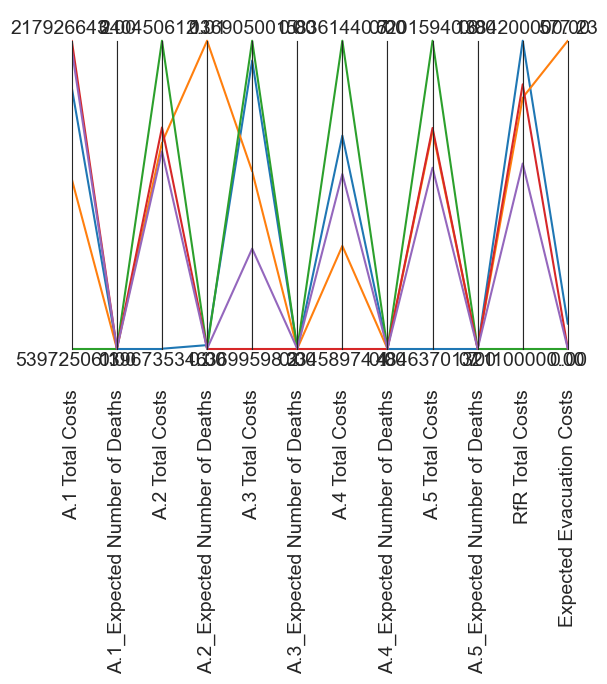

In [25]:
import matplotlib.pyplot as plt
from ema_workbench.analysis import parcoords

data = results.loc[:, [o.name for o in model.outcomes]]

# Define thresholds for "low" values, here using the 10th percentile for each
threshold_deaths = data['A.5_Expected Number of Deaths'].quantile(0.1)
threshold_costs = data['A.5 Total Costs'].quantile(0.1)

# Filter rows where both outcomes are below their thresholds
filtered_data = data[
    (data['A.5_Expected Number of Deaths'] <= threshold_deaths) &
    (data['A.5 Total Costs'] <= threshold_costs)
]

limits = parcoords.get_limits(filtered_data)

plt.figure(figsize=(60, 30))  # wide figure

paraxes = parcoords.ParallelAxes(limits)
paraxes.plot(filtered_data)

plt.show()

In [28]:
# Calculate 10th percentile thresholds for each column
threshold_costs = results['A.5 Total Costs'].quantile(0.1)
threshold_deaths = results['A.5_Expected Number of Deaths'].quantile(0.1)

# Filter rows where both are below the thresholds
filtered_results = results[
    (results['A.5 Total Costs'] <= threshold_costs) &
    (results['A.5_Expected Number of Deaths'] <= threshold_deaths)
]

In [29]:
filtered_results

,0_RfR 0,0_RfR 1,0_RfR 2,1_RfR 0,1_RfR 1,1_RfR 2,2_RfR 0,2_RfR 1,2_RfR 2,3_RfR 0,...,A.2 Total Costs,A.2_Expected Number of Deaths,A.3 Total Costs,A.3_Expected Number of Deaths,A.4 Total Costs,A.4_Expected Number of Deaths,A.5 Total Costs,A.5_Expected Number of Deaths,RfR Total Costs,Expected Evacuation Costs
7,1,1,1,1,1,0,1,0,1,0,...,1.396735e+08,0.000087,1.321846e+08,0.0,5.069078e+07,0.0,4.846370e+07,0.0,1.384200e+09,46.613192
13,1,1,1,1,1,0,0,0,0,1,...,2.070968e+08,0.007404,1.058509e+08,0.0,4.177288e+07,0.0,5.804407e+07,0.0,1.187900e+09,577.226412
26,1,1,0,0,0,0,0,0,1,0,...,2.404506e+08,0.000000,1.369050e+08,0.0,5.836144e+07,0.0,6.201594e+07,0.0,3.211000e+08,0.000000
43,1,0,1,0,1,0,1,1,1,1,...,2.120685e+08,0.000000,6.369960e+07,0.0,3.345897e+07,0.0,5.817663e+07,0.0,1.233700e+09,0.000000
63,0,0,1,0,0,0,0,0,0,1,...,2.042489e+08,0.000000,8.749894e+07,0.0,4.758096e+07,0.0,5.642588e+07,0.0,9.604000e+08,0.000000


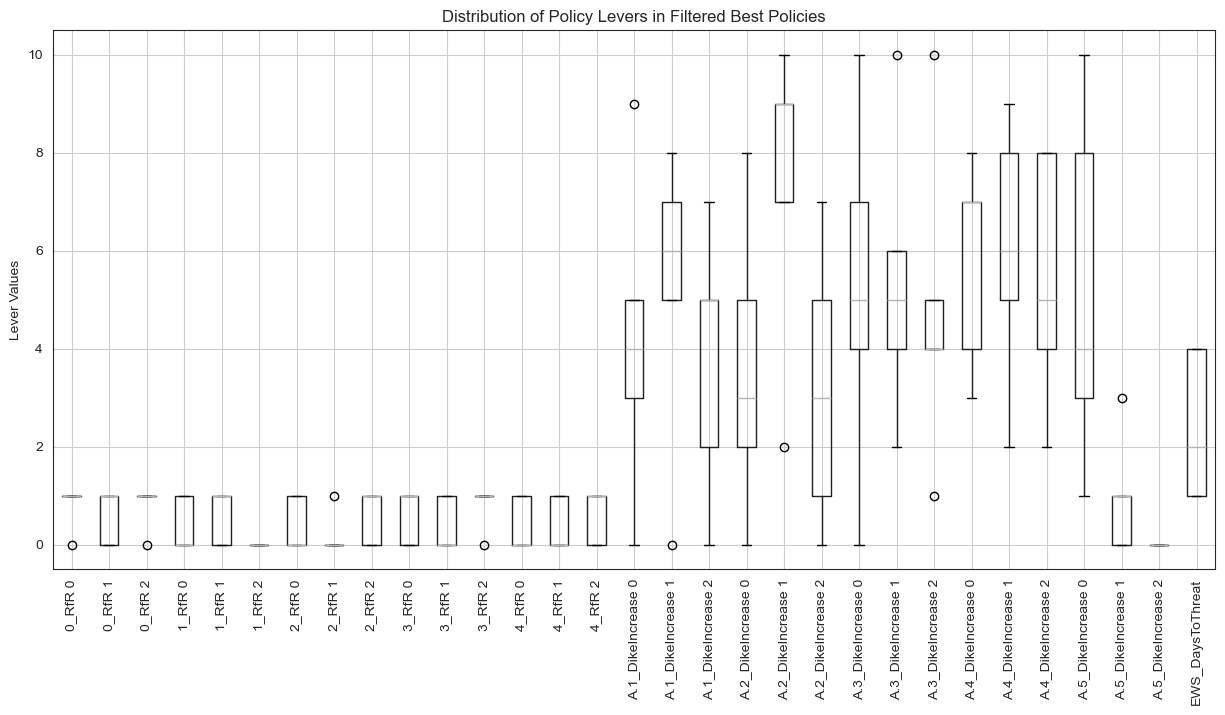

In [30]:
import matplotlib.pyplot as plt

# Assuming filtered_results is your filtered DataFrame from before

# List of policy levers (same as you provided)
policy_levers = [
    '0_RfR 0', '0_RfR 1', '0_RfR 2', '1_RfR 0', '1_RfR 1', '1_RfR 2',
    '2_RfR 0', '2_RfR 1', '2_RfR 2', '3_RfR 0', '3_RfR 1', '3_RfR 2',
    '4_RfR 0', '4_RfR 1', '4_RfR 2',
    'A.1_DikeIncrease 0', 'A.1_DikeIncrease 1', 'A.1_DikeIncrease 2',
    'A.2_DikeIncrease 0', 'A.2_DikeIncrease 1', 'A.2_DikeIncrease 2',
    'A.3_DikeIncrease 0', 'A.3_DikeIncrease 1', 'A.3_DikeIncrease 2',
    'A.4_DikeIncrease 0', 'A.4_DikeIncrease 1', 'A.4_DikeIncrease 2',
    'A.5_DikeIncrease 0', 'A.5_DikeIncrease 1', 'A.5_DikeIncrease 2',
    'EWS_DaysToThreat'
]

# Check if all levers exist in filtered_results columns (optional)
existing_levers = [lever for lever in policy_levers if lever in filtered_results.columns]

# Plot boxplot for those policy levers
plt.figure(figsize=(15, 7))
filtered_results[existing_levers].boxplot(rot=90)
plt.title("Distribution of Policy Levers in Filtered Best Policies")
plt.ylabel("Lever Values")
plt.show()